# Russia — EDA, TTC-модели, SHAP

**Что тут:** EDA → Stage-1 (Through-The-Cycle) → проверка H1 и H2 по России.

* **H1.** Ансамбли (RF, XGBoost) выдают более высокий ROC-AUC, чем Logit, но у них больше **зазор train–test** (переобучение).
* **H2.** Сумма `|SHAP|` по блокам **Ликвидность + НМА** выше, чем по блоку **Леверидж**.

**Правила научрука:** без SMOTE, `class_weight` ≈ 1:10, stratified split.

**Артефакты** сохраняются в `reports/russia/` — все графики как PNG, таблицы как CSV, финальные вердикты в `ru_summary.md`. Этого достаточно, чтобы вставить в текст диплома.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

from xgboost import XGBClassifier
import shap

RNG = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports/russia')
REPORTS.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = REPORTS / f'{name}.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    print(f'  saved → {path}')

# Сюда копим текстовые выводы для итогового markdown-отчёта
_report_lines = ['# Russia — Stage-1 (TTC) results\n']
def log(msg=''):
    print(msg)
    _report_lines.append(msg)

df = pd.read_csv(PROCESSED / 'ru_panel_cleaned.csv', encoding='utf-8-sig')
print('Shape:', df.shape)
df.head(3)


Shape: (88714, 20)


,Регистрационный номер,year,EBIT,Активы всего,Внеоборотные активы,Выручка,Дебиторская задолженность,Денежные средства и денежные эквиваленты,Долгосрочные обязательства,Капитал и резервы,Краткосрочные обязательства,Кредиторская задолженность,Нематериальные активы,Оборотные активы,Проценты к уплате,Сальдо денежных потоков от текущих операций,Среднесписочная численность работников,Чистая прибыль (убыток),bankrupt_company,is_bankrupt
0,1022401483928,2012,4294000.0,10581000.0,6784000.0,3744000.0,438000.0,208000.0,0.0,10075000.0,506000.0,506000.0,0.0,3797000.0,14000.0,3061000.0,2.5,3987000.0,1,0
1,1022401483928,2013,2999000.0,12968000.0,6530000.0,3906000.0,6423000.0,15000.0,0.0,12853000.0,115000.0,115000.0,0.0,6438000.0,14000.0,3061000.0,2.5,2778000.0,1,0
2,1022401483928,2014,2614000.0,18961000.0,17531000.0,4111000.0,89000.0,35000.0,0.0,15260000.0,3701000.0,2601000.0,0.0,1430000.0,14000.0,-630000.0,2.5,2384000.0,1,0


## 1. Feature engineering

Формируем ratios по блокам H2:

* **Liquidity:** `current_ratio`, `cash_to_assets`, `cash_to_cl`, `wc_to_assets`
* **Innovation:** `intangibles_to_assets`
* **Leverage:** `debt_to_assets`, `debt_to_equity`, `lt_debt_to_assets`, `interest_coverage`
* **Profitability:** `roa`, `net_margin`, `operating_margin`, `cfo_to_assets`
* **Size:** `log_assets`, `log_revenue`

Винзоризация 1/99% — типичные IT-ратио сильно скошены.


In [2]:
ID_COL = 'Регистрационный номер'
TARGET = 'is_bankrupt'

A  = 'Активы  всего'
CA = 'Оборотные активы'
CASH = 'Денежные средства и денежные эквиваленты'
INT_A = 'Нематериальные активы'
EQ = 'Капитал и резервы'
LT_L = 'Долгосрочные обязательства'
ST_L = 'Краткосрочные обязательства'
REV = 'Выручка'
EBIT = 'EBIT'
NI = 'Чистая прибыль (убыток)'
INTEREST = 'Проценты к уплате'
CFO = 'Сальдо денежных потоков от текущих операций'

def safe_div(a, b):
    b = b.replace(0, np.nan)
    return a / b

panel = df.copy()
total_debt = panel[LT_L] + panel[ST_L]

panel['current_ratio']         = safe_div(panel[CA], panel[ST_L])
panel['cash_to_assets']        = safe_div(panel[CASH], panel[A])
panel['cash_to_cl']            = safe_div(panel[CASH], panel[ST_L])
panel['wc_to_assets']          = safe_div(panel[CA] - panel[ST_L], panel[A])

panel['intangibles_to_assets'] = safe_div(panel[INT_A], panel[A])

panel['debt_to_assets']        = safe_div(total_debt, panel[A])
panel['debt_to_equity']        = safe_div(total_debt, panel[EQ])
panel['lt_debt_to_assets']     = safe_div(panel[LT_L], panel[A])
panel['interest_coverage']     = safe_div(panel[EBIT], panel[INTEREST])

panel['roa']              = safe_div(panel[NI], panel[A])
panel['net_margin']       = safe_div(panel[NI], panel[REV])
panel['operating_margin'] = safe_div(panel[EBIT], panel[REV])
panel['cfo_to_assets']    = safe_div(panel[CFO], panel[A])

panel['log_assets']  = np.log1p(panel[A].clip(lower=0))
panel['log_revenue'] = np.log1p(panel[REV].clip(lower=0))

FEATURES = [
    'current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets',
    'intangibles_to_assets',
    'debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage',
    'roa', 'net_margin', 'operating_margin', 'cfo_to_assets',
    'log_assets', 'log_revenue',
]

FEATURE_GROUPS = {
    'Liquidity':     ['current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets'],
    'Innovation':    ['intangibles_to_assets'],
    'Leverage':      ['debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage'],
    'Profitability': ['roa', 'net_margin', 'operating_margin', 'cfo_to_assets'],
    'Size':          ['log_assets', 'log_revenue'],
}

panel[FEATURES] = panel[FEATURES].replace([np.inf, -np.inf], np.nan)
for c in FEATURES:
    lo, hi = panel[c].quantile([0.01, 0.99])
    panel[c] = panel[c].clip(lo, hi)
panel[FEATURES] = panel[FEATURES].fillna(panel[FEATURES].median(numeric_only=True))

panel[FEATURES + [TARGET]].describe().T.round(3).to_csv(REPORTS / 'ru_feature_stats.csv', encoding='utf-8-sig')
print(f'Фичи: {len(FEATURES)}  |  stats → reports/russia/ru_feature_stats.csv')
panel[FEATURES].describe().T.round(3)


Фичи: 15  |  stats → reports/russia/ru_feature_stats.csv


,count,mean,std,min,25%,50%,75%,max
current_ratio,88714.0,10.737,29.845,0.012,1.117,2.269,6.739,227.177
cash_to_assets,88714.0,0.287,0.312,0.000,0.030,0.155,0.476,1.000
cash_to_cl,88714.0,3.398,10.731,0.000,0.067,0.402,1.673,82.092
wc_to_assets,88714.0,-0.253,4.386,-38.481,0.087,0.482,0.800,0.995
intangibles_to_assets,88714.0,0.077,0.417,0.000,0.000,0.000,0.000,3.690
debt_to_assets,88714.0,3.299,16.626,0.004,0.188,0.527,0.964,147.100
debt_to_equity,88714.0,9.197,46.819,-42.986,0.072,0.455,2.171,378.513
lt_debt_to_assets,88714.0,1.045,5.713,0.000,0.000,0.000,0.122,50.000
interest_coverage,88714.0,165.278,1267.100,-1460.333,9.355,9.355,9.355,17049.570
roa,88714.0,0.211,1.695,-8.700,0.004,0.135,0.467,10.000


## 2. EDA

### 2.1 Классовый дисбаланс


  saved → ..\reports\russia\01_class_distribution.png


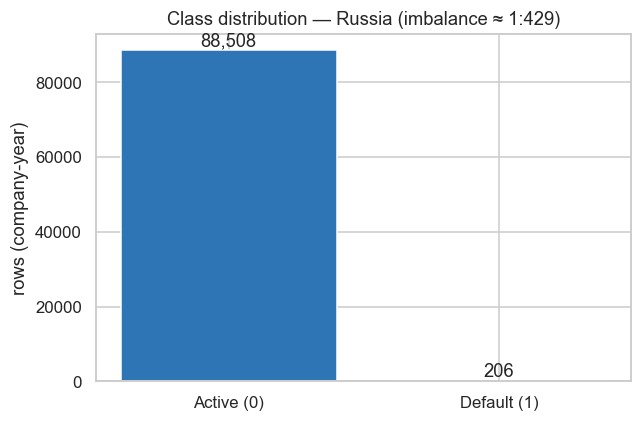


## Class balance
* Active (0): **88,508**
* Default (1): **206**
* Positive share: **0.232%**  (≈ 1:429)


In [3]:
vc = panel[TARGET].value_counts()
n_active  = int(vc.get(0, 0))
n_default = int(vc.get(1, 0))
ratio = n_default / (n_active + n_default)
counts = pd.Series({'Active (0)': n_active, 'Default (1)': n_default})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['#2E75B6', '#C00000'])
ax.set_title(f'Class distribution — Russia (imbalance ≈ 1:{n_active//max(n_default,1)})')
ax.set_ylabel('rows (company-year)')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
save_fig(fig, '01_class_distribution'); plt.show()

log(f'\n## Class balance\n* Active (0): **{n_active:,}**')
log(f'* Default (1): **{n_default:,}**')
log(f'* Positive share: **{ratio*100:.3f}%**  (≈ 1:{n_active//max(n_default,1)})')

### 2.2 Violin plots — по классу


  saved → ..\reports\russia\02_violin_by_class.png


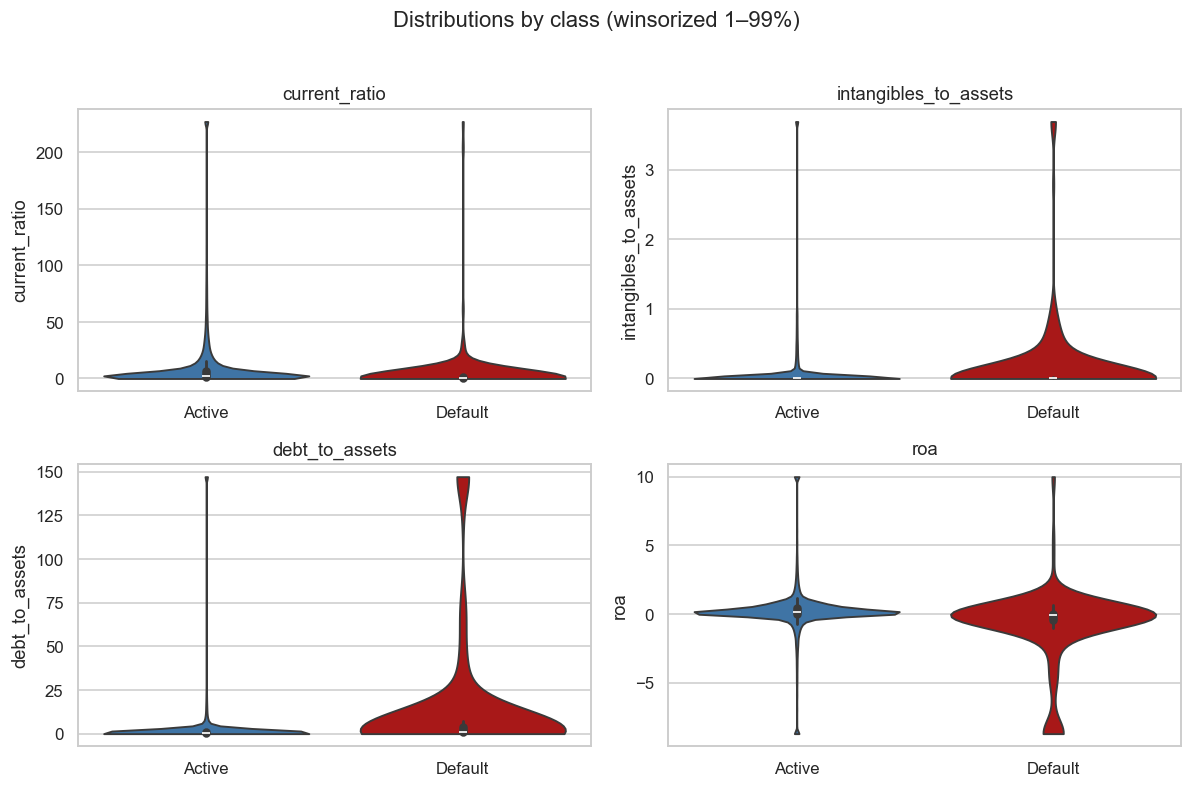

,current_ratio,intangibles_to_assets,debt_to_assets,roa
_lbl,,,,
Active,2.276,0.0,0.526,0.135
Default,0.842,0.0,1.124,-0.031


In [4]:
panel['_lbl'] = panel[TARGET].map({0:'Active', 1:'Default'})
show = ['current_ratio', 'intangibles_to_assets', 'debt_to_assets', 'roa']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), show):
    sns.violinplot(data=panel, x='_lbl', y=col, ax=ax,
                   palette={'Active':'#2E75B6','Default':'#C00000'}, cut=0)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle('Distributions by class (winsorized 1–99%)', y=1.02)
plt.tight_layout()
save_fig(fig, '02_violin_by_class'); plt.show()

med = panel.groupby('_lbl')[show].median().round(3)
med.to_csv(REPORTS / 'ru_medians_by_class.csv', encoding='utf-8-sig')
med


### 2.3 Корреляционная матрица


  saved → ..\reports\russia\03_correlation_heatmap.png


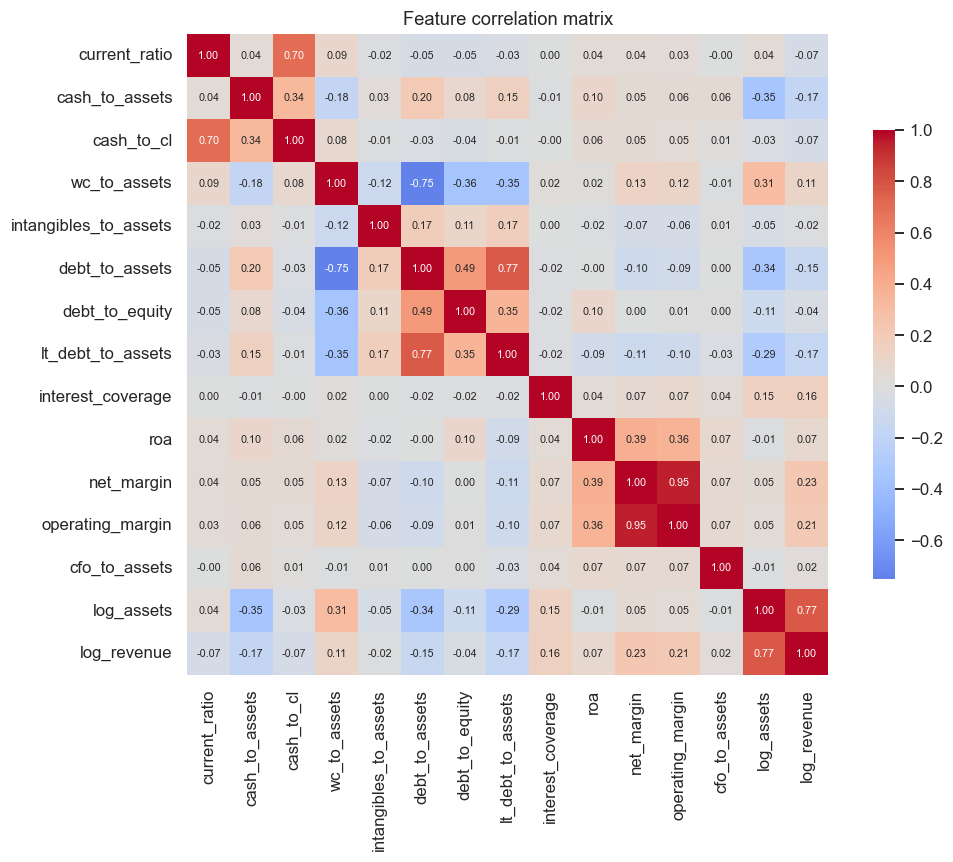

|corr| > 0.85:
  net_margin × operating_margin: +0.95


In [5]:
corr = panel[FEATURES].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, cbar_kws={'shrink':0.7}, annot_kws={'size':7}, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
save_fig(fig, '03_correlation_heatmap'); plt.show()

corr.round(3).to_csv(REPORTS / 'ru_correlation_matrix.csv', encoding='utf-8-sig')

high = (corr.abs() > 0.85) & (corr.abs() < 1.0)
pairs = [(i,j,corr.loc[i,j]) for i in corr.index for j in corr.columns if i<j and high.loc[i,j]]
print('|corr| > 0.85:')
for p in pairs: print(f'  {p[0]} × {p[1]}: {p[2]:+.2f}')
if not pairs: print('  нет — мультиколлинеарность под контролем')


## 3. Train / Test split — **group-aware (по компаниям)**

Stratified 80/20 **на уровне `Регистрационный номер`**: у каждой компании все её годы попадают либо целиком в train, либо целиком в test. Без этого «отпечаток компании» утекает между фолдами и ансамбли запоминают конкретные РН вместо того, чтобы учить обобщаемый сигнал.

Стратификация реализована раздельно по активным и по компаниям-банкротам, чтобы сохранить пропорцию дефолтов в тесте (иначе на 206 банкротах случайный split может дать 0–50 банкротов в тесте).

Temporal split отложен до Stage-2 (PIT).

In [6]:
X = panel[FEATURES].values
y = panel[TARGET].values
groups = panel[ID_COL].values

# company-level stratified split: 80/20 отдельно по bankrupt- и active-компаниям
company_label = panel.groupby(ID_COL)[TARGET].max()  # 1, если у компании есть target=1
companies_b = np.array(company_label[company_label == 1].index.values, copy=True)
companies_a = np.array(company_label[company_label == 0].index.values, copy=True)

_rng = np.random.default_rng(RNG)
_rng.shuffle(companies_b)
_rng.shuffle(companies_a)

def _split_ids(arr, test_frac=0.2):
    n_test = int(round(len(arr) * test_frac))
    return arr[n_test:], arr[:n_test]

train_b, test_b = _split_ids(companies_b, 0.20)
train_a, test_a = _split_ids(companies_a, 0.20)

train_ids = set(train_b) | set(train_a)
test_ids  = set(test_b)  | set(test_a)

mask_train = panel[ID_COL].isin(train_ids).values
mask_test  = panel[ID_COL].isin(test_ids).values

X_train, y_train = X[mask_train], y[mask_train]
X_test,  y_test  = X[mask_test],  y[mask_test]
g_train, g_test  = groups[mask_train], groups[mask_test]

print(f'Train: {X_train.shape},  defaults = {y_train.sum()}  ({y_train.mean()*100:.2f}%)')
print(f'Test:  {X_test.shape},   defaults = {y_test.sum()}   ({y_test.mean()*100:.2f}%)')
print(f'Companies — train: {len(train_ids):,}, test: {len(test_ids):,}, '
      f'overlap: {len(train_ids & test_ids)} (должно быть 0)')
print(f'Bankrupt companies — train: {len(train_b)}, test: {len(test_b)}')

Train: (70851, 15),  defaults = 165  (0.23%)
Test:  (17863, 15),   defaults = 41   (0.23%)
Companies — train: 8,103, test: 2,026, overlap: 0 (должно быть 0)
Bankrupt companies — train: 165, test: 41


## 4. Stage-1 модели (TTC)

`class_weight` / `scale_pos_weight` **вычисляются динамически** как `n_neg / n_pos` на **train** (~1:400) — это стандартный cost-sensitive baseline. Прежнее значение `POS_WEIGHT=10` недооценивало дисбаланс в десятки раз и было главной причиной катастрофически низкого PR-AUC на тесте.

In [7]:
POS_WEIGHT = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print(f'POS_WEIGHT (n_neg / n_pos на train) = {POS_WEIGHT:.1f}')

logit = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight={0: 1, 1: POS_WEIGHT},
                               solver='liblinear', random_state=RNG)),
])
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=3,
    class_weight={0: 1, 1: POS_WEIGHT}, n_jobs=-1, random_state=RNG,
)
xgb = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=POS_WEIGHT,
    eval_metric='aucpr', tree_method='hist', random_state=RNG, n_jobs=-1,
)

models = {'Logistic Regression': logit, 'Random Forest': rf, 'XGBoost': xgb}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f'✓ trained {name}')

POS_WEIGHT (n_neg / n_pos на train) = 428.4
✓ trained Logistic Regression


✓ trained Random Forest


✓ trained XGBoost


## 5. H1 — Train vs Test и Cross-Validation (overfit check)

* Single split: group-aware (компании не пересекаются между train/test).
* **Stratified Group 5-Fold CV** (`StratifiedGroupKFold`) — устойчивость метрик на 206 дефолтах. Репортится mean ± std.
* Приоритетная метрика для дисбаланса ≈ 1:429 — **PR-AUC**. ROC-AUC приводится для совместимости с паспортом, но на extreme-imbalance завышает оптимизм.

In [8]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

def scores(model, X, y):
    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X)[:, 1]
    else:
        p = model.decision_function(X)
    return roc_auc_score(y, p), average_precision_score(y, p)

# --- (a) Single-split метрики (group-aware 80/20) ---
rows = []
for name, m in models.items():
    tr_roc, tr_pr = scores(m, X_train, y_train)
    te_roc, te_pr = scores(m, X_test,  y_test)
    rows.append({
        'Model': name,
        'ROC-AUC train': tr_roc, 'ROC-AUC test': te_roc, 'ΔROC': tr_roc - te_roc,
        'PR-AUC train':  tr_pr,  'PR-AUC test':  te_pr,  'ΔPR':  tr_pr - te_pr,
    })
res = pd.DataFrame(rows).set_index('Model').round(4)
res.to_csv(REPORTS / 'ru_h1_metrics.csv', encoding='utf-8-sig')
print('Single split (group-aware):')
print(res)

# --- (b) 5-fold Stratified Group K-Fold CV ---
skgf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RNG)
cv_rows = []
for name, m_proto in models.items():
    roc_tr_l, pr_tr_l, roc_te_l, pr_te_l = [], [], [], []
    for tr_idx, te_idx in skgf.split(X, y, groups=groups):
        # Пересчёт веса в каждом фолде от train-дисбаланса
        yt = y[tr_idx]
        pw = float((yt == 0).sum() / max((yt == 1).sum(), 1))
        mdl = clone(m_proto)
        if isinstance(mdl, Pipeline):
            mdl.set_params(clf__class_weight={0: 1, 1: pw})
        elif isinstance(mdl, RandomForestClassifier):
            mdl.set_params(class_weight={0: 1, 1: pw})
        elif isinstance(mdl, XGBClassifier):
            mdl.set_params(scale_pos_weight=pw)
        mdl.fit(X[tr_idx], yt)
        r_tr, p_tr = scores(mdl, X[tr_idx], yt)
        r_te, p_te = scores(mdl, X[te_idx], y[te_idx])
        roc_tr_l.append(r_tr); pr_tr_l.append(p_tr)
        roc_te_l.append(r_te); pr_te_l.append(p_te)
    cv_rows.append({
        'Model': name,
        'ROC-AUC test mean': np.mean(roc_te_l),
        'ROC-AUC test std':  np.std(roc_te_l),
        'PR-AUC test mean':  np.mean(pr_te_l),
        'PR-AUC test std':   np.std(pr_te_l),
        'ΔROC (train−test)': np.mean(roc_tr_l) - np.mean(roc_te_l),
        'ΔPR (train−test)':  np.mean(pr_tr_l)  - np.mean(pr_te_l),
    })
cv = pd.DataFrame(cv_rows).set_index('Model').round(4)
cv.to_csv(REPORTS / 'ru_h1_cv_metrics.csv', encoding='utf-8-sig')
print('\n5-fold Stratified Group K-Fold CV:')
print(cv)
res

Single split (group-aware):
                     ROC-AUC train  ROC-AUC test    ΔROC  PR-AUC train  \
Model                                                                    
Logistic Regression         0.8786        0.8370  0.0416        0.0405   
Random Forest               0.9997        0.8614  0.1383        0.8131   
XGBoost                     0.9997        0.8833  0.1164        0.8482   

                     PR-AUC test     ΔPR  
Model                                     
Logistic Regression       0.1140 -0.0735  
Random Forest             0.0851  0.7280  
XGBoost                   0.0642  0.7840  



5-fold Stratified Group K-Fold CV:
                     ROC-AUC test mean  ROC-AUC test std  PR-AUC test mean  \
Model                                                                        
Logistic Regression             0.8514            0.0168            0.0597   
Random Forest                   0.8708            0.0240            0.0455   
XGBoost                         0.8538            0.0111            0.0434   

                     PR-AUC test std  ΔROC (train−test)  ΔPR (train−test)  
Model                                                                      
Logistic Regression           0.0149             0.0247           -0.0047  
Random Forest                 0.0121             0.1288            0.7321  
XGBoost                       0.0242             0.1459            0.8026  


,ROC-AUC train,ROC-AUC test,ΔROC,PR-AUC train,PR-AUC test,ΔPR
Model,,,,,,
Logistic Regression,0.8786,0.8370,0.0416,0.0405,0.1140,-0.0735
Random Forest,0.9997,0.8614,0.1383,0.8131,0.0851,0.7280
XGBoost,0.9997,0.8833,0.1164,0.8482,0.0642,0.7840


In [9]:
best_roc_name = res['ROC-AUC test'].idxmax()
best_pr_name  = res['PR-AUC test'].idxmax()
logit_delta   = res.loc['Logistic Regression', 'ΔROC']
ens_delta_max = res.loc[['Random Forest','XGBoost'], 'ΔROC'].max()
ens_roc_max   = res.loc[['Random Forest','XGBoost'], 'ROC-AUC test'].max()
logit_roc     = res.loc['Logistic Regression', 'ROC-AUC test']
ens_pr_max    = res.loc[['Random Forest','XGBoost'], 'PR-AUC test'].max()
logit_pr      = res.loc['Logistic Regression', 'PR-AUC test']

log('\n## H1 — переобучение на малом числе дефолтов')
log(f'* Split: **group-aware** (по `Регистрационный номер`); POS_WEIGHT = n_neg/n_pos на train = **{POS_WEIGHT:.1f}**.')
log(f'* Best test ROC-AUC: **{best_roc_name}** ({res.loc[best_roc_name,"ROC-AUC test"]:.4f}); '
    f'Logit ROC-AUC = {logit_roc:.4f}.')
log(f'* Best test PR-AUC: **{best_pr_name}** ({res.loc[best_pr_name,"PR-AUC test"]:.4f}); '
    f'Logit PR-AUC = {logit_pr:.4f}.')
log(f'* ΔROC (train−test): Logit **{logit_delta:+.4f}**, max ensemble **{ens_delta_max:+.4f}**.')
log('')
log('**5-fold Stratified Group K-Fold CV (mean ± std):**')
for name in cv.index:
    log(f'* {name}: ROC {cv.loc[name,"ROC-AUC test mean"]:.3f}±{cv.loc[name,"ROC-AUC test std"]:.3f}, '
        f'PR {cv.loc[name,"PR-AUC test mean"]:.3f}±{cv.loc[name,"PR-AUC test std"]:.3f}, '
        f'ΔROC {cv.loc[name,"ΔROC (train−test)"]:+.3f}')

cond_roc   = ens_roc_max > logit_roc
cond_delta = ens_delta_max > logit_delta
logit_wins_pr = logit_pr >= ens_pr_max

if cond_roc and cond_delta:
    v_roc = '✅ По ROC-AUC H1 выполняется: ансамбли точнее и переобучаются сильнее.'
elif not cond_roc and cond_delta:
    v_roc = '⚠️ По ROC-AUC H1 частично: ансамбли не точнее Logit, но переобучаются сильнее.'
elif cond_roc and not cond_delta:
    v_roc = '⚠️ По ROC-AUC H1 частично: ансамбли точнее, но зазор сопоставим.'
else:
    v_roc = '❌ По ROC-AUC H1 не выполняется.'

if logit_wins_pr:
    v_pr = '✅ По PR-AUC (адекватной метрике при 1:{:.0f} дисбалансе) **Logit превосходит ансамбли** — главный аргумент H1.'.format(POS_WEIGHT)
else:
    v_pr = '⚠️ По PR-AUC ансамбли не проигрывают Logit — H1 ослабляется.'

verdict = v_roc + '\n\n' + v_pr
log(f'\n{verdict}')
print('\n' + verdict)


## H1 — переобучение на малом числе дефолтов
* Split: **group-aware** (по `Регистрационный номер`); POS_WEIGHT = n_neg/n_pos на train = **428.4**.
* Best test ROC-AUC: **XGBoost** (0.8833); Logit ROC-AUC = 0.8370.
* Best test PR-AUC: **Logistic Regression** (0.1140); Logit PR-AUC = 0.1140.
* ΔROC (train−test): Logit **+0.0416**, max ensemble **+0.1383**.

**5-fold Stratified Group K-Fold CV (mean ± std):**
* Logistic Regression: ROC 0.851±0.017, PR 0.060±0.015, ΔROC +0.025
* Random Forest: ROC 0.871±0.024, PR 0.045±0.012, ΔROC +0.129
* XGBoost: ROC 0.854±0.011, PR 0.043±0.024, ΔROC +0.146

✅ По ROC-AUC H1 выполняется: ансамбли точнее и переобучаются сильнее.

✅ По PR-AUC (адекватной метрике при 1:428 дисбалансе) **Logit превосходит ансамбли** — главный аргумент H1.

✅ По ROC-AUC H1 выполняется: ансамбли точнее и переобучаются сильнее.

✅ По PR-AUC (адекватной метрике при 1:428 дисбалансе) **Logit превосходит ансамбли** — главный аргумент H1.


## 6. H2 — SHAP для лучшего ансамбля


Best ensemble by PR-AUC test: Random Forest (PR-AUC=0.0851, ROC-AUC=0.8614)


SHAP shape: (17863, 15)


  saved → ..\reports\russia\04_shap_summary.png


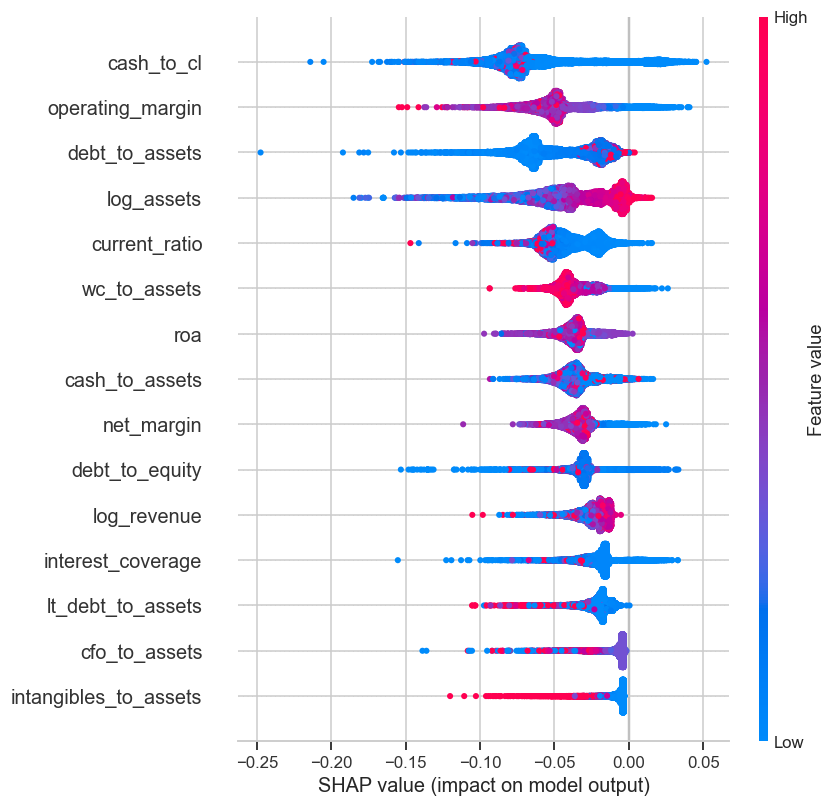

In [10]:
ensemble_pr = res.loc[['Random Forest', 'XGBoost'], 'PR-AUC test']
best_name = ensemble_pr.idxmax()
best_model = models[best_name]
print(f'Best ensemble by PR-AUC test: {best_name} '
      f'(PR-AUC={ensemble_pr.max():.4f}, ROC-AUC={res.loc[best_name, "ROC-AUC test"]:.4f})')

explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(X_test)

# shap может вернуть list или 3D-массив — нормализуем под бинарную задачу
if isinstance(sv, list):
    sv = sv[1]
elif hasattr(sv, 'ndim') and sv.ndim == 3:
    sv = sv[:, :, 1]
print('SHAP shape:', sv.shape)

plt.figure()
shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False)
fig = plt.gcf()
save_fig(fig, '04_shap_summary'); plt.show()

Top features by mean |SHAP|:
cash_to_cl               0.0659
operating_margin         0.0486
debt_to_assets           0.0452
log_assets               0.0417
current_ratio            0.0408
wc_to_assets             0.0372
roa                      0.0365
cash_to_assets           0.0354
net_margin               0.0332
debt_to_equity           0.0309
log_revenue              0.0236
interest_coverage        0.0223
lt_debt_to_assets        0.0216
cfo_to_assets            0.0098
intangibles_to_assets    0.0082

Σ|SHAP| по блокам:
Liquidity        0.1793
Profitability    0.1281
Leverage         0.1200
Size             0.0653
Innovation       0.0082
  saved → ..\reports\russia\05_h2_group_importance.png


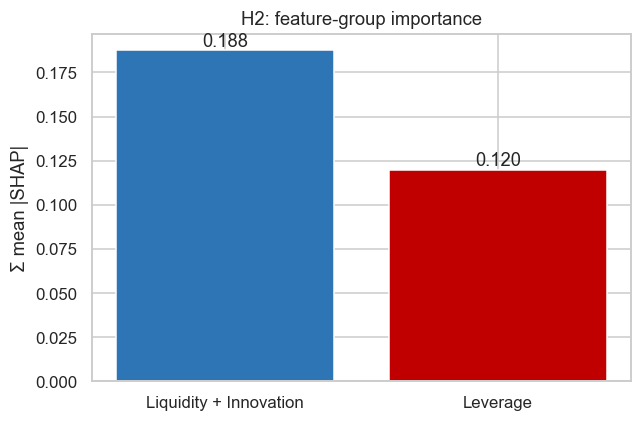


## H2 — Liquidity+Innovation vs Leverage (SHAP)
* Best ensemble (by PR-AUC test): **Random Forest** (PR-AUC=0.0851, ROC-AUC=0.8614)
* Σ|SHAP| Liquidity + Innovation = **0.1875**
* Σ|SHAP| Leverage               = **0.1200**
* Ratio = **1.56×**

✅ **H2 ПОДТВЕРЖДАЕТСЯ**: в IT-секторе России ликвидность и НМА важнее рычага.

✅ **H2 ПОДТВЕРЖДАЕТСЯ**: в IT-секторе России ликвидность и НМА важнее рычага.


In [11]:
mean_abs = np.abs(sv).mean(axis=0)
fi = pd.Series(mean_abs, index=FEATURES).sort_values(ascending=False)
fi.round(4).to_csv(REPORTS / 'ru_shap_feature_importance.csv', header=['mean_abs_shap'], encoding='utf-8-sig')
print('Top features by mean |SHAP|:')
print(fi.round(4).to_string())

group_sum = {g: fi[cols].sum() for g, cols in FEATURE_GROUPS.items()}
group_df = pd.Series(group_sum).sort_values(ascending=False).round(4)
group_df.to_csv(REPORTS / 'ru_shap_group_importance.csv', header=['sum_abs_shap'], encoding='utf-8-sig')
print('\nΣ|SHAP| по блокам:')
print(group_df.to_string())

liq_inn = group_df.get('Liquidity', 0) + group_df.get('Innovation', 0)
lev     = group_df.get('Leverage',   0)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Liquidity + Innovation', 'Leverage'],
              [liq_inn, lev], color=['#2E75B6', '#C00000'])
ax.set_ylabel('Σ mean |SHAP|')
ax.set_title('H2: feature-group importance')
for b, v in zip(bars, [liq_inn, lev]):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout()
save_fig(fig, '05_h2_group_importance'); plt.show()

log('\n## H2 — Liquidity+Innovation vs Leverage (SHAP)')
log(f'* Best ensemble (by PR-AUC test): **{best_name}** '
    f'(PR-AUC={ensemble_pr.max():.4f}, ROC-AUC={res.loc[best_name, "ROC-AUC test"]:.4f})')
log(f'* Σ|SHAP| Liquidity + Innovation = **{liq_inn:.4f}**')
log(f'* Σ|SHAP| Leverage               = **{lev:.4f}**')
if lev > 0:
    log(f'* Ratio = **{liq_inn/lev:.2f}×**')

if liq_inn > lev:
    verdict2 = '✅ **H2 ПОДТВЕРЖДАЕТСЯ**: в IT-секторе России ликвидность и НМА важнее рычага.'
else:
    verdict2 = '❌ H2 НЕ подтверждается: рычаг остаётся доминирующим предиктором.'
log(f'\n{verdict2}')
print('\n' + verdict2)

## 7. Сохраняем итоговый отчёт


In [12]:
summary_path = REPORTS / 'ru_summary.md'
summary_path.write_text('\n'.join(_report_lines), encoding='utf-8')
print(f'✅ Итоговый отчёт: {summary_path}')
print('\nВсе артефакты в reports/russia/:')
for p in sorted(REPORTS.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')


✅ Итоговый отчёт: ..\reports\russia\ru_summary.md

Все артефакты в reports/russia/:
  01_class_distribution.png  (36.1 KB)
  02_violin_by_class.png  (115.7 KB)
  03_correlation_heatmap.png  (237.6 KB)
  04_shap_summary.png  (212.7 KB)
  05_h2_group_importance.png  (33.7 KB)
  ru_correlation_matrix.csv  (1.8 KB)
  ru_feature_stats.csv  (1.0 KB)
  ru_h1_cv_metrics.csv  (0.3 KB)
  ru_h1_metrics.csv  (0.2 KB)
  ru_medians_by_class.csv  (0.1 KB)
  ru_shap_feature_importance.csv  (0.3 KB)
  ru_shap_group_importance.csv  (0.1 KB)
  ru_summary.md  (1.5 KB)


## 8. Что получилось

В папке `reports/russia/`:

| файл | что внутри |
|---|---|
| `01_class_distribution.png` | столбики баланса классов |
| `02_violin_by_class.png` | violin по 4 ключевым метрикам |
| `03_correlation_heatmap.png` | heatmap корреляций |
| `04_shap_summary.png` | SHAP summary (лучший ансамбль) |
| `05_h2_group_importance.png` | Σ\|SHAP\| по блокам для H2 |
| `ru_h1_metrics.csv` | train/test ROC/PR + Δ по всем трём моделям |
| `ru_shap_feature_importance.csv` | mean \|SHAP\| по фичам |
| `ru_shap_group_importance.csv` | суммы по блокам |
| `ru_correlation_matrix.csv`, `ru_feature_stats.csv`, `ru_medians_by_class.csv` | EDA-таблицы |
| `ru_summary.md` | готовый текст с вердиктами H1 и H2 — можно вставить в §3.2–3.3 |

Всё это — вход для Stage-2 (PIT) и для сравнения с Китаем.
